# Setup

In [1]:
# Imports
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.special import expit
from scipy.optimize import minimize
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, pearsonr, wilcoxon

In [2]:
# Reproducibility
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

In [3]:
# Project paths
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "PD_data"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

# Create output directories if they do not exist
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [4]:
# Dataset settings
RUN_A_KEY = "data_train"
RUN_B_KEY = "data_test"

N_EXPECTED_PARTICIPANTS = 49

# Data loading and preparation

In [5]:
# Load participant files
mat_files = sorted(DATA_DIR.glob("*.mat"))

assert DATA_DIR.exists(), f"Data direcotry not found: {DATA_DIR}"
assert len(mat_files) == N_EXPECTED_PARTICIPANTS, (
    f"Expected {N_EXPECTED_PARTICIPANTS} participant files, "
    f"but found {len(mat_files)}."
)
print("Number of participant files:", len(mat_files))
print("First file:", mat_files[0].name)

Number of participant files: 49
First file: 2rrjzhgj9.mat


In [6]:
# Check one file
example = sio.loadmat(mat_files[0])

print(example.keys())
print("Run A shape:", example[RUN_A_KEY].shape)
print("Run B shape:", example[RUN_B_KEY].shape)
print("Labels:", example["data_labels"])

dict_keys(['__header__', '__version__', '__globals__', 'data_labels', 'data_test', 'data_train'])
Run A shape: (200, 8)
Run B shape: (200, 8)
Labels: [[array(['certOutcome'], dtype='<U11')
  array(['uncOutcome'], dtype='<U10')
  array(['outcome prob.'], dtype='<U13')
  array(['action (1=certain, 2=uncertain, 0=missing)'], dtype='<U42')
  array(['p_cert'], dtype='<U6')
  array(['condition (1=reward,2=loss)'], dtype='<U27')
  array(['RT'], dtype='<U2') array(['odds'], dtype='<U4')]]


In [7]:
# Column indices
COL_R_CERT = 0      # 0 = certain outcome
COL_R_UNCERT = 1    # 1 = uncertain outcome
COL_P = 2           # 2 = outcome probability
COL_CHOICE = 3      # 3 = action, where 1=certain, 2=uncertain, 0=missing
COL_P_CERT = 4
COL_CONDITION = 5   # 5 = condition, where 1=reward, 2=loss
COL_RT = 6          # 6 = reaction time
COL_ODDS = 7

In [8]:
# Prepare trial data
def prepare_data(data):
    data = np.asarray(data, dtype=float)

    # Remove missing choices and invalid RTs
    valid = (
        np.isin(data[:, COL_CHOICE], [1, 2])
        & np.isfinite(data[:, COL_RT])
        & (data[:, COL_RT] > 0)
    )
    data = data[valid]

    r_cert = data[:, COL_R_CERT]
    r_uncert = data[:, COL_R_UNCERT]
    p = data[:, COL_P]
    choice = data[:, COL_CHOICE]
    condition = data[:, COL_CONDITION]
    rt = data[:, COL_RT]

    # Convert probabilities from percentages to proportions
    if np.nanmax(p) > 1:
        p = p / 100.0

    # Recode choice:
    # original 1 = certain -> y = 1
    # original 2 = uncertain -> y = 0
    y = (choice == 1).astype(int)

    return r_cert, r_uncert, p, y, rt, condition

In [9]:
# Sanity checks
summary = []

for file in mat_files:
    participant = sio.loadmat(file)

    for run_name, run_key in [("Run A", RUN_A_KEY), ("Run B", RUN_B_KEY)]:
        data = np.asarray(participant[run_key], dtype=float)

        choice = data[:, COL_CHOICE]
        condition = data[:, COL_CONDITION]
        rt = data[:, COL_RT]

        choice_missing = (choice == 0) | ~np.isfinite(choice)
        rt_missing = ~np.isfinite(rt)

        summary.append({
            "participant": file.stem,
            "run": run_name,
            "n_trials": len(data),
            "missing_choice": choice_missing.sum(),
            "missing_rt": rt_missing.sum(),
            "choice_missing_rt_valid": np.sum(choice_missing & ~rt_missing),
            "choice_valid_rt_missing": np.sum(~choice_missing & rt_missing),
            "choice_missing_rt_missing": np.sum(choice_missing & rt_missing),
            "nonpositive_rt": np.sum(np.isfinite(rt) & (rt <= 0)),
            "reward_trials": np.sum(condition == 1),
            "loss_trials": np.sum(condition == 2)
        })

sanity_df = pd.DataFrame(summary)

display(sanity_df.groupby("run").agg({
    "n_trials": "sum",
    "missing_choice": "sum",
    "missing_rt": "sum",
    "choice_missing_rt_valid": "sum",
    "choice_valid_rt_missing": "sum",
    "choice_missing_rt_missing": "sum",
    "nonpositive_rt": "sum",
    "reward_trials": "sum",
    "loss_trials": "sum",
}))

,n_trials,missing_choice,missing_rt,choice_missing_rt_valid,choice_valid_rt_missing,choice_missing_rt_missing,nonpositive_rt,reward_trials,loss_trials
run,,,,,,,,,
Run A,9800,51,51,0,0,51,0,4900,4900
Run B,9800,17,17,0,0,17,0,4900,4900


# Shared Model Components

**Fix valuation model and choice rule**

Use the hyperbolic probability discounting model and couple it to choice via a softmax on the value difference:

In [10]:
# Hyperbolic subjective valuation
def compute_subjective_values(r_cert, r_uncert, p, h):
    """Compute subjective values under hyperbolic probability discounting."""

    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)

    theta = (1 - p) / p

    v_cert = r_cert
    v_uncert = r_uncert / (1 + h * theta)

    return v_cert, v_uncert

In [11]:
# Subjective value difference
def compute_value_difference(v_cert, v_uncert):
    """Compute subjective value difference."""

    return v_cert - v_uncert

In [12]:
# Logistic choice rule
def compute_choice_probability(delta_v, beta):
    """Compute probability of choosing the certain option."""

    return expit(beta * delta_v)

In [13]:
# Bernoulli choice log-likelihood
def choice_log_likelihood(y, pi):
    """Bernoulli log-likelihood for binary choices."""

    eps = 1e-12
    pi = np.clip(pi, eps, 1 - eps)

    return np.sum(y * np.log(pi) + (1 - y) * np.log(1 - pi))

In [14]:
# Shifted log-normal RT likelihood
def shifted_lognormal_log_likelihood(rt, mu, sigma, tau):
    """Log-likelihood of RT under a shifted log-normal distribution."""

    if sigma <= 0 or tau < 0:
        return -np.inf

    rt_shifted = rt - tau

    if np.any(rt_shifted <= 0):
        return -np.inf

    log_rt = np.log(rt_shifted)

    return np.sum(-np.log(rt_shifted) - np.log(sigma) - 0.5 * np.log(2 * np.pi) - ((log_rt - mu) ** 2) / (2 * sigma ** 2))

# Model Specifications

## Choice-only model:

In [15]:
def nll_choice_only(params, data):

    beta, h = params

    # Safety check
    if beta < 0 or h < 0:
        return np.inf

    # Prepare data
    r_cert, r_uncert, p, y, _, _ = prepare_data(data)

    # Shared valuation
    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)

    # Delta V
    delta_v = compute_value_difference(v_cert, v_uncert)

    # Choice probability
    pi = compute_choice_probability(delta_v, beta)

    # Bernoulli choice likelihood
    log_likelihood_choice = choice_log_likelihood(y, pi)

    return -log_likelihood_choice

## RT Models

RT is assumed to increase when the subjective value difference is close to zero, capturing a difficulty / conflict hypothesis in which decisions are slowest near indifference and faster when one option is clearly better.

### 1: Absolute conflict

Combine the shared choice model with an absolute-conflict RT mapping.

In [16]:
def nll_absolute_conflict(params, data):

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0:
        return np.inf

    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Absolute conflict
    abs_conflict = np.abs(delta_v)
    mu = a - b * abs_conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt

    return -total_log_likelihood

### 2: Squared conflict

Combine choice model with squared conflict.

In [17]:
def nll_squared_conflict(params, data):

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0:
        return np.inf

    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Squared conflict
    conflict = delta_v ** 2
    mu = a - b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt

    return -total_log_likelihood

### 3: Exponential value-difference mapping

Combine choice model with exponential mapping.

In [18]:
def nll_exponential(params, data):

    beta, h, a, b, sigma, tau = params

    # Safety check
    if beta < 0 or b < 0 or h < 0:
        return np.inf

    r_cert, r_uncert, p, y, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    log_likelihood_choice = choice_log_likelihood(y, pi)

    # Exponential mapping
    conflict = np.exp(-(delta_v ** 2))
    mu = a + b * conflict

    log_likelihood_rt = shifted_lognormal_log_likelihood(rt, mu, sigma, tau)
    total_log_likelihood = log_likelihood_choice + log_likelihood_rt

    return -total_log_likelihood

# Fit choice-only model

In [19]:
def initial_conditions_choice_only():
    beta_values = [0.001, 0.1, 1, 3, 10, 30, 100]
    h_values = [0.001, 0.1, 1, 3, 10, 30, 100]
    initial_conditions = []
    for beta in beta_values:
        for h in h_values:
            initial_conditions.append([beta, h])

    return initial_conditions

In [20]:
def fit_choice_only(data):
    bounds = [(0, None), (0, None)] # beta, h
    initial_conditions = initial_conditions_choice_only()

    best_result = None
    best_nll = np.inf

    all_results = []

    for x0 in initial_conditions:
        result = minimize(
            nll_choice_only,
            x0=x0,
            args=(data,),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 500,
                "ftol": 1e-7
            }
        )

        all_results.append(result)

        if np.isfinite(result.fun) and result.fun < best_nll:
            best_result = result
            best_nll = result.fun

    return best_result, all_results

# Predict choices of choice-only model

In [21]:
def predict_choice_only(params, data):
    beta, h = params
    r_cert, r_uncert, p, y_true, _, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(
        r_cert=r_cert,
        r_uncert=r_uncert,
        p=p,
        h=h
    )

    delta_v = compute_value_difference(
        v_cert=v_cert,
        v_uncert=v_uncert
    )

    pi = compute_choice_probability(
        delta_v=delta_v,
        beta=beta
    )

    y_pred = (pi >= 0.5).astype(int)

    return y_true, y_pred, pi

In [22]:
def compute_accuracy(x_true, x_pred):
    return np.mean(x_true == x_pred) * 100

Do the actual fitting of the choice-only model:

In [23]:
results_choice_only = []

for file in mat_files:

    mat = sio.loadmat(file)
    data_train = mat["data_train"]
    data_test = mat["data_test"]

    # Choice-only fitted on train data
    co_train_result, co_train_all = fit_choice_only(data_train)

    if co_train_result is None:
        print(f"Training failed for {file.stem}")
        continue

    co_train_params = co_train_result.x

    # Choice-only fitted on test data for reliability check
    co_test_result, co_test_all = fit_choice_only(data_test)

    if co_test_result is None:
        print(f"Test fitting failed for {file.stem}")
        continue

    co_test_params = co_test_result.x

    # Test choice prediction
    x_true_co, x_pred_co, pi_co = predict_choice_only(
        params=co_train_params,
        data=data_test
    )

    co_test_acc = compute_accuracy(x_true_co, x_pred_co)

    co_test_nll = nll_choice_only(
        co_train_params,
        data_test
    )

    results_choice_only.append({
        "participant": file.stem,
        "co_train_beta": co_train_params[0],
        "co_train_h": co_train_params[1],
        "co_test_beta": co_test_params[0],
        "co_test_h": co_test_params[1],
        "co_train_nll": co_train_result.fun,
        "co_test_nll": co_test_nll,
        "co_train_success": co_train_result.success,
        "co_test_success": co_test_result.success,
        "co_test_accuracy": co_test_acc
    })

df_choice_only = pd.DataFrame(results_choice_only)
df_choice_only.head()

,participant,co_train_beta,co_train_h,co_test_beta,co_test_h,co_train_nll,co_test_nll,co_train_success,co_test_success,co_test_accuracy
0,2rrjzhgj9,0.068924,1.311927,0.017364,25.334550,111.466557,153.745804,True,True,50.5
1,3lmzwis6r,0.385170,1.186613,0.520034,0.805554,100.282304,99.173047,True,True,74.0
2,4f8msviwg,0.053096,0.453735,0.160200,0.849301,105.568802,122.444451,True,True,78.0
3,52b64k0rp,0.004943,1360.948458,0.000000,0.796172,138.265558,138.196220,True,True,56.0
4,5wlmihb4c,0.030212,2.945797,0.022781,15505.035789,131.053785,205.533500,True,True,31.5


# Results of the choice-only fitting and reliability

In [46]:
df_choice_only[[
    "co_test_accuracy",
    "co_train_beta",
    "co_train_h",
    "co_test_beta",
    "co_test_h"
]].describe()

,co_test_accuracy,co_train_beta,co_train_h,co_test_beta,co_test_h
count,49.000000,49.000000,49.000000,49.000000,49.000000
mean,64.400099,0.105906,32.905574,0.137048,1390.303054
std,15.376167,0.258166,194.205037,0.238669,5209.148957
min,31.500000,0.000000,0.095482,0.000000,0.000000
25%,56.000000,0.021211,1.109051,0.015980,0.668333
50%,66.666667,0.046819,2.257764,0.052181,1.064078
75%,74.500000,0.070825,3.782589,0.151528,8.333444
max,92.500000,1.779555,1360.948458,1.386547,25548.206342


In [25]:
print("Number of participants:", len(df_choice_only))
print("Successful train optimizations:", df_choice_only["co_train_success"].sum())
print("Failed train optimizations:", (~df_choice_only["co_train_success"]).sum())
print("Successful test optimizations:", df_choice_only["co_test_success"].sum())
print("Failed test optimizations:", (~df_choice_only["co_test_success"]).sum())

Number of participants: 49
Successful train optimizations: 49
Failed train optimizations: 0
Successful test optimizations: 49
Failed test optimizations: 0


In [26]:
def compute_train_test_correlation(df, train_col, test_col):
    valid = np.isfinite(df[train_col]) & np.isfinite(df[test_col])

    if valid.sum() < 3:
        return np.nan, np.nan

    r, p = pearsonr(df.loc[valid, train_col], df.loc[valid, test_col])
    return r, p

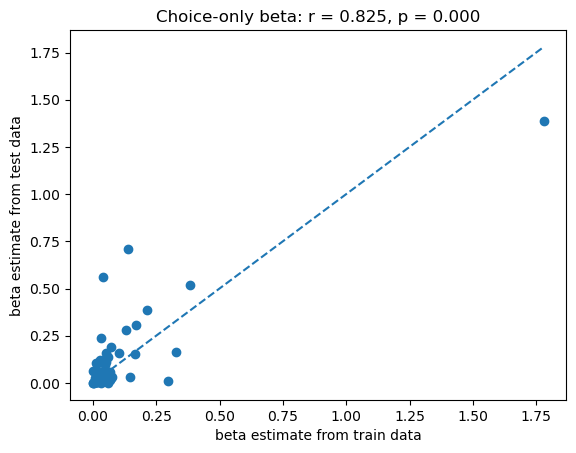

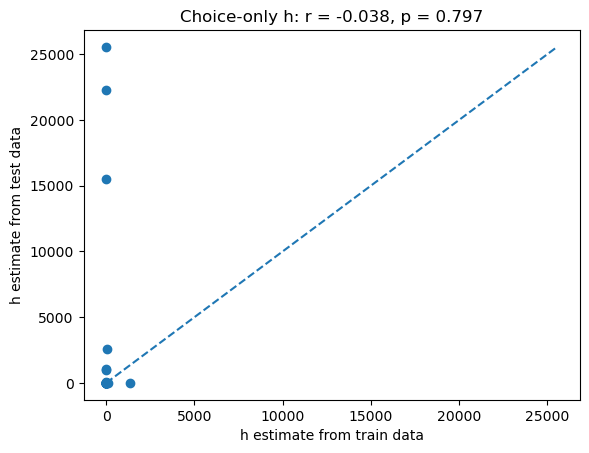

,model,parameter,r,p
0,choice-only,beta,0.824633,3.263315e-13
1,choice-only,h,-0.037775,7.966440e-01


In [27]:
co_parameters = ["beta", "h"]

co_corr_results = []

for param in co_parameters:
    train_col = f"co_train_{param}"
    test_col = f"co_test_{param}"

    r, p = compute_train_test_correlation(df_choice_only, train_col, test_col)

    plt.figure()
    plt.scatter(df_choice_only[train_col], df_choice_only[test_col])

    min_val = min(df_choice_only[train_col].min(), df_choice_only[test_col].min())
    max_val = max(df_choice_only[train_col].max(), df_choice_only[test_col].max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel(f"{param} estimate from train data")
    plt.ylabel(f"{param} estimate from test data")
    plt.title(f"Choice-only {param}: r = {r:.3f}, p = {p:.3f}")
    plt.show()

    co_corr_results.append({
        "model": "choice-only",
        "parameter": param,
        "r": r,
        "p": p
    })

df_co_corr = pd.DataFrame(co_corr_results)
df_co_corr

# Parameter recovery for the choice-only model

In [28]:
# Function to generate choices:
def simulate_choice_data(data, beta_true, h_true, random_state=None):

    rng = np.random.default_rng(random_state)

    r_cert, r_uncert, p, _, rt, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(
        r_cert=r_cert,
        r_uncert=r_uncert,
        p=p,
        h=h_true
    )

    delta_v = compute_value_difference(
        v_cert=v_cert,
        v_uncert=v_uncert
    )

    pi = compute_choice_probability(
        delta_v=delta_v,
        beta=beta_true
    )

    # Generate choices
    y_sim = rng.binomial(
        n=1,
        p=pi
    )

    return r_cert, r_uncert, p, y_sim, rt

In [29]:
def make_simulated_matrix(orig_data, beta_true, h_true, random_state=None):

    # Copy original data
    data = np.asarray(orig_data, dtype=float).copy()

    valid = (data[:, 3] != 0) & np.isfinite(data[:, 6]) & (data[:, 6] > 0)

    _, _, _, y_sim, _ = simulate_choice_data(
        orig_data,
        beta_true=beta_true,
        h_true=h_true,
        random_state=random_state
    )

    # Convert back to original coding:
    # 1 = certain
    # 2 = uncertain
    data[valid, 3] = np.where(y_sim == 1, 1, 2)

    return data

In [30]:
def parameter_recovery(data, beta_true, h_true, n_simulations=10, participant=None):

    recovery_results = []

    for sim in range(n_simulations):

        simulated_data = make_simulated_matrix(
            data,
            beta_true=beta_true,
            h_true=h_true,
            random_state=sim
        )

        result, _ = fit_choice_only(simulated_data)

        if result is None or not result.success:
            continue

        beta_recovered = result.x[0]
        h_recovered = result.x[1]

        recovery_results.append({
            "participant": participant,
            "simulation": sim,
            "beta_true": beta_true,
            "h_true": h_true,
            "beta_recovered": beta_recovered,
            "h_recovered": h_recovered,
            "nll": result.fun,
            "success": result.success
        })

    return pd.DataFrame(recovery_results)

In [31]:
co_beta_values = [0.1, 1, 10]
co_h_values = [0.1, 1, 10]

co_all_recovery = []

# Take 10 participants for recovery
recovery_files = mat_files[:10]

for file in recovery_files:

    print(f"Running recovery for {file.stem}...")

    mat = sio.loadmat(file)
    data_train = mat["data_train"]

    co_participant_results = []

    for beta_true in co_beta_values:
        for h_true in co_h_values:

            recovery = parameter_recovery(
                data=data_train,
                beta_true=beta_true,
                h_true=h_true,
                n_simulations=10,
                participant=file.stem
            )

            co_participant_results.append(recovery)

    co_participant_results = pd.concat(
        co_participant_results,
        ignore_index=True
    )

    co_all_recovery.append(co_participant_results)

df_co_recovery = pd.concat(
    co_all_recovery,
    ignore_index=True
)

print(df_co_recovery.shape)
print(df_co_recovery.head())


Running recovery for 2rrjzhgj9...
Running recovery for 3lmzwis6r...
Running recovery for 4f8msviwg...
Running recovery for 52b64k0rp...
Running recovery for 5wlmihb4c...
Running recovery for 6owg3par9...
Running recovery for 8py7pm5i0...
Running recovery for 95vrrzevd...
Running recovery for bh348lli7...
Running recovery for c0ry57ax9...
(899, 8)
  participant  simulation  beta_true  h_true  beta_recovered  h_recovered  \
0   2rrjzhgj9           0        0.1     0.1        0.074044     0.099421   
1   2rrjzhgj9           1        0.1     0.1        0.061036     0.088683   
2   2rrjzhgj9           2        0.1     0.1        0.124623     0.112129   
3   2rrjzhgj9           3        0.1     0.1        0.102395     0.044177   
4   2rrjzhgj9           4        0.1     0.1        0.075935     0.095148   

         nll  success  
0  89.399574     True  
1  92.310802     True  
2  80.836483     True  
3  80.883779     True  
4  88.797048     True  


In [32]:
beta_r, beta_p = pearsonr(
    df_co_recovery["beta_true"],
    df_co_recovery["beta_recovered"]
)

beta_rmse = np.sqrt(
    np.mean(
        (
            df_co_recovery["beta_recovered"]
            - df_co_recovery["beta_true"]
        ) ** 2
    )
)

beta_bias = np.mean(
    df_co_recovery["beta_recovered"]
    - df_co_recovery["beta_true"]
)

h_r, h_p = pearsonr(
    df_co_recovery["h_true"],
    df_co_recovery["h_recovered"]
)

h_rmse = np.sqrt(
    np.mean(
        (
            df_co_recovery["h_recovered"]
            - df_co_recovery["h_true"]
        ) ** 2
    )
)

h_bias = np.mean(
    df_co_recovery["h_recovered"]
    - df_co_recovery["h_true"]
)

print("Parameter recovery")
print("------------------")

print(f"beta:")
print(f"  correlation = {beta_r:.3f}")
print(f"  RMSE = {beta_rmse:.3f}")
print(f"  bias = {beta_bias:.3f}")

print(f"\nh:")
print(f"  correlation = {h_r:.3f}")
print(f"  RMSE = {h_rmse:.3f}")
print(f"  bias = {h_bias:.3f}")

Parameter recovery
------------------
beta:
  correlation = 0.362
  RMSE = 99.982
  bias = 22.268

h:
  correlation = 0.995
  RMSE = 0.443
  bias = 0.022


Plots for parameter recovery

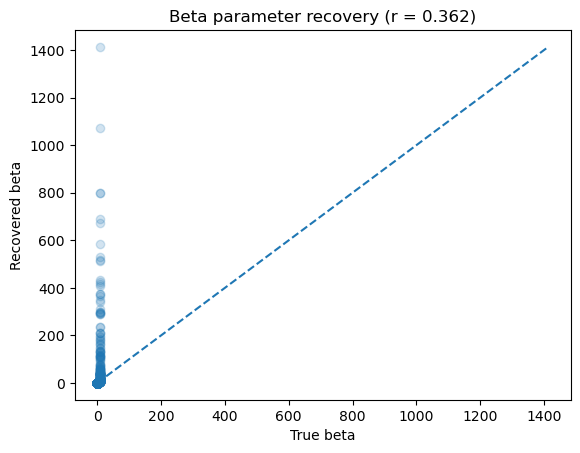

In [33]:
plt.figure()

plt.scatter(df_co_recovery["beta_true"], df_co_recovery["beta_recovered"], alpha=0.2)

min_val = min(df_co_recovery["beta_true"].min(), df_co_recovery["beta_recovered"].min())
max_val = max(df_co_recovery["beta_true"].max(), df_co_recovery["beta_recovered"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True beta")
plt.ylabel("Recovered beta")
plt.title(f"Beta parameter recovery (r = {beta_r:.3f})")
plt.show()

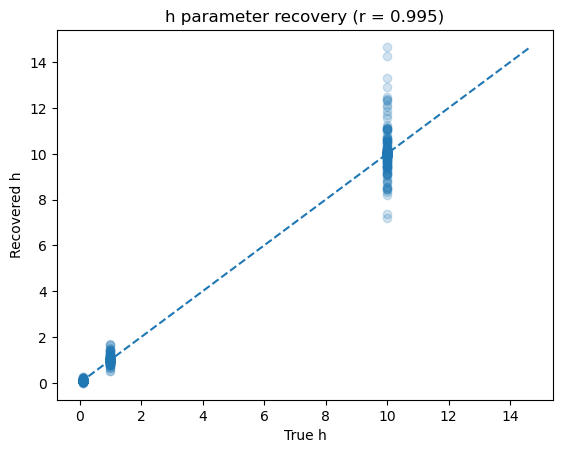

In [34]:
plt.figure()

plt.scatter(df_co_recovery["h_true"], df_co_recovery["h_recovered"], alpha=0.2)

min_val = min(df_co_recovery["h_true"].min(), df_co_recovery["h_recovered"].min())
max_val = max(df_co_recovery["h_true"].max(), df_co_recovery["h_recovered"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True h")
plt.ylabel("Recovered h")
plt.title(f"h parameter recovery (r = {h_r:.3f})")
plt.show()

# Absolute-Conflict Model

## Fit model

In [180]:
def initial_conditions_absolute_conflict():
    # Order: [beta, h, a, b, sigma, tau]
    return [
        [0.1, 0.5, 0.5, 0.1, 0.3, 0.05],
        [1.0, 1.0, 0.7, 0.1, 0.4, 0.05],
        [3.0, 1.0, 1.0, 0.2, 0.5, 0.10],
        [1.0, 3.0, 1.0, 0.5, 0.6, 0.10],
        [3.0, 3.0, 1.5, 0.3, 0.7, 0.15],
        [0.05, 2.0, 7.0,  0.0005, 0.45, 0.10],  
        [0.15, 3.0, 7.5,  0.0010, 0.55, 0.10],
        [0.02, 1.0, 6.5,  0.0002, 0.35, 0.05],
        [1.0,  5.0, 8.0,  0.0050, 0.70, 0.15],
    ]

In [ ]:
def fit_absolute_conflict(data):

    _, _, _, _, rt, _ = prepare_data(data)

    tau_upper = np.min(rt) - 1e-6

    if tau_upper <= 1e-6:
        return None, []

    # Dynamic tau starting values. They are guaranteed to be below tau_upper.    
    tau_starts = [
        tau_upper * 0.01,
        tau_upper * 0.10,
        tau_upper * 0.25,
        tau_upper * 0.50
]   

    initial_conditions = []

    for beta, h, a, b, sigma, _ in initial_conditions_absolute_conflict():
        for tau in tau_starts:
            initial_conditions.append([beta, h, a, b, sigma, tau])

    bounds = [
        (0, None),        # beta
        (0, None),        # h
        (None, None),        # a
        (0, None),        # b
        (1e-6, None),        # sigma
        (0, tau_upper)    # tau
    ]

    best_result = None
    best_nll = np.inf
    all_results = []

    for x0 in initial_conditions:

        result = minimize(
            nll_absolute_conflict,
            x0=x0,
            args=(data,),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 500,
                "ftol": 1e-7
            }
        )

        all_results.append(result)

        if (
            np.isfinite(result.fun)
            and np.all(np.isfinite(result.x))
            and result.fun < best_nll
        ):
            best_result = result
            best_nll = result.fun

    return best_result, all_results

### Prediction and Evaluation

In [182]:
def predict_absolute_conflict(params, data):
    
    beta, h, a, b, sigma, tau = params
    r_cert, r_uncert, p, y_true, rt_true, condition = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(r_cert, r_uncert, p, h)
    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = compute_choice_probability(delta_v, beta)
    pi = np.clip(pi, 1e-12, 1 - 1e-12)
    y_pred = (pi >= 0.5).astype(int)

    choice_loglik = y_true * np.log(pi) + (1 - y_true) * np.log(1 - pi)

    abs_conflict = np.abs(delta_v)
    mu = a - b * abs_conflict
    rt_shifted = rt_true - tau
    valid_rt = rt_shifted > 0

    rt_loglik = np.full_like(rt_true, np.nan, dtype=float)
    if np.any(valid_rt):
        log_rt = np.log(rt_shifted[valid_rt])
        rt_loglik[valid_rt] = (
            -log_rt
            - 0.5 * np.log(2 * np.pi * sigma ** 2)
            - ((log_rt - mu[valid_rt]) ** 2) / (2 * sigma ** 2)
        )

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "pi": pi,
        "choice_loglik": choice_loglik,
        "rt_true": rt_true,
        "rt_loglik": rt_loglik,
        "valid_rt": valid_rt,
        "condition": condition
    }


In [183]:
def summarize_absolute_conflict_prediction(prediction_dict):
    
    y_true = prediction_dict["y_true"]
    y_pred = prediction_dict["y_pred"]
    choice_loglik = prediction_dict["choice_loglik"]
    rt_loglik = prediction_dict["rt_loglik"]
    valid_rt = prediction_dict["valid_rt"]

    choice_nll = -np.sum(choice_loglik)
    rt_nll = -np.sum(rt_loglik[valid_rt])

    return {
        "choice_accuracy": np.mean(y_true == y_pred) * 100,
        "choice_nll": choice_nll,
        "rt_nll": rt_nll,
        "n_trials": len(y_true),
        "n_valid_rt": int(valid_rt.sum())
    }


In [184]:
def summarize_absolute_conflict_by_condition(prediction_dict):
    
    condition = prediction_dict["condition"]

    rows = []
    for condition_code, condition_name in [(1, "reward"), (2, "loss")]:
        mask = condition == condition_code

        if mask.sum() == 0:
            continue

        condition_prediction = {
            "y_true": prediction_dict["y_true"][mask],
            "y_pred": prediction_dict["y_pred"][mask],
            "choice_loglik": prediction_dict["choice_loglik"][mask],
            "rt_loglik": prediction_dict["rt_loglik"][mask],
            "valid_rt": prediction_dict["valid_rt"][mask]
        }

        metrics = summarize_absolute_conflict_prediction(condition_prediction)
        metrics["condition"] = condition_name
        rows.append(metrics)

    return rows


### Participant-Level Fitting Pipeline

In [ ]:
def run_absolute_conflict_pipeline(mat_files):
    summary_rows = []
    condition_rows = []

    for file in mat_files:

        mat = sio.loadmat(file)
        
        data_train = mat[RUN_A_KEY]
        data_test = mat[RUN_B_KEY]

        train_result, _ = fit_absolute_conflict(data_train)
        test_result, _ = fit_absolute_conflict(data_test)

        if train_result is None:
            print(f"Absolute-conflict train fit failed for {file.stem}")
            continue

        train_params = train_result.x
        test_params = test_result.x if test_result is not None else np.array([np.nan] * 6)

        test_prediction = predict_absolute_conflict(train_params, data_test)
        test_metrics = summarize_absolute_conflict_prediction(test_prediction)

        summary_rows.append({
            "participant": file.stem,
            "abs_train_success": bool(train_result.success),
            "abs_test_success": bool(test_result.success) if test_result is not None else False,
            "abs_train_nll": float(train_result.fun),
            "abs_test_refit_nll": float(test_result.fun) if test_result is not None else np.nan,
            "abs_test_pred_choice_accuracy": test_metrics["choice_accuracy"],
            "abs_test_pred_choice_nll": test_metrics["choice_nll"],
            "abs_test_pred_rt_nll": test_metrics["rt_nll"],
            "abs_train_beta": train_params[0], "abs_train_h": train_params[1],
            "abs_train_a": train_params[2], "abs_train_b": train_params[3],
            "abs_train_sigma": train_params[4], "abs_train_tau": train_params[5],
            "abs_test_beta": test_params[0], "abs_test_h": test_params[1],
            "abs_test_a": test_params[2], "abs_test_b": test_params[3],
            "abs_test_sigma": test_params[4], "abs_test_tau": test_params[5],
        })

        # we will use this later for reward vs loss analysis
        for cond_metrics in summarize_absolute_conflict_by_condition(test_prediction):
            condition_rows.append({
                "participant": file.stem,
                "condition": cond_metrics["condition"],
                "abs_choice_accuracy": cond_metrics["choice_accuracy"],
                "abs_choice_nll": cond_metrics["choice_nll"],
                "abs_rt_nll": cond_metrics["rt_nll"],
                "abs_n_trials": cond_metrics["n_trials"],
                "abs_n_valid_rt": cond_metrics["n_valid_rt"],
            })

    return pd.DataFrame(summary_rows), pd.DataFrame(condition_rows)


In [213]:
df_abs_summary, df_abs_condition = run_absolute_conflict_pipeline(mat_files)

print("Summary:", df_abs_summary.shape)
print("Condition:", df_abs_condition.shape)

Summary: (49, 20)
Condition: (98, 7)


In [219]:
df_abs_summary[[
    "abs_train_beta", "abs_train_h", "abs_train_a",
    "abs_train_b", "abs_train_sigma", "abs_train_tau"
]].describe()


,abs_train_beta,abs_train_h,abs_train_a,abs_train_b,abs_train_sigma,abs_train_tau
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.104351,2.494239,7.511477,0.000693,0.524560,290.645735
std,0.257725,2.328262,0.410461,0.000970,0.184243,217.572734
min,0.000000,0.000000,5.913657,0.000000,0.317468,2.147325
25%,0.020528,1.019548,7.303529,0.000000,0.444241,98.731189
50%,0.046719,1.911753,7.504502,0.000368,0.482807,321.028293
75%,0.070852,2.853727,7.756155,0.001064,0.538732,458.037067
max,1.772725,10.284533,8.270765,0.004495,1.535635,767.050207


## Parameter-recovery

In [ ]:
def simulate_absolute_conflict_data(
    data, beta_true, h_true, a_true, b_true,
    sigma_true, tau_true, random_state=None
):
    rng = np.random.default_rng(random_state)

    base = np.asarray(data, dtype=float).copy()

    valid = (
        np.isin(base[:, COL_CHOICE], [1, 2])
        & np.isfinite(base[:, COL_RT])
        & (base[:, COL_RT] > 0)
    )

    r_cert, r_uncert, p, _, _, _ = prepare_data(data)

    v_cert, v_uncert = compute_subjective_values(
        r_cert, r_uncert, p, h_true
    )

    delta_v = compute_value_difference(v_cert, v_uncert)

    pi = np.clip(
        compute_choice_probability(delta_v, beta_true),
        1e-12, 1 - 1e-12
    )

    y_sim = rng.binomial(1, pi)

    # Absolute conflict
    conflict = np.abs(delta_v)
    mu = a_true - b_true * conflict

    log_rt = rng.normal(
        loc=mu,
        scale=sigma_true,
        size=len(mu)
    )

    rt_sim = np.exp(log_rt) + tau_true

    base[valid, COL_CHOICE] = np.where(y_sim == 1, 1, 2)
    base[valid, COL_RT] = rt_sim

    return base

In [226]:
def parameter_recovery_absolute_conflict(
    data, true_params, n_simulations=10, participant=None
):

    beta_true, h_true, a_true, b_true, sigma_true, tau_true = true_params

    rows = []

    for sim in range(n_simulations):

        simulated_data = simulate_absolute_conflict_data(
            data,
            beta_true,
            h_true,
            a_true,
            b_true,
            sigma_true,
            tau_true,
            random_state=sim
        )

        result, _ = fit_absolute_conflict(simulated_data)

        if (
            result is not None
            and np.isfinite(result.fun)
            and np.all(np.isfinite(result.x))
        ):

            rec = result.x

        else:

            rec = [np.nan] * 6

        rows.append({
            "participant": participant,
            "simulation": sim,

            "beta_true": beta_true,
            "h_true": h_true,
            "a_true": a_true,
            "b_true": b_true,
            "sigma_true": sigma_true,
            "tau_true": tau_true,

            "beta_recovered": rec[0],
            "h_recovered": rec[1],
            "a_recovered": rec[2],
            "b_recovered": rec[3],
            "sigma_recovered": rec[4],
            "tau_recovered": rec[5],

            "nll": result.fun if result is not None else np.nan,
            "success": bool(result.success) if result is not None else False
        })

    return pd.DataFrame(rows)

Parameter Recovery Execution

In [227]:
abs_true_parameter_sets = [
    # (beta,  h,    a,    b,    sigma, tau)
    (0.047, 1.91, 7.50, 0.0004, 0.48, 300),   # baseline (median)
    (0.030, 1.20, 7.00, 0.0003, 0.40, 150),   # mixed low
    (0.100, 2.80, 7.90, 0.0030, 0.60, 500),   # mixed high
]

abs_all_recovery = []

for file in mat_files[:10]:

    print(f"Recovery for {file.stem}...")

    data_train = sio.loadmat(file)[RUN_A_KEY]

    participant_results = []

    for true_params in abs_true_parameter_sets:

        recovery = parameter_recovery_absolute_conflict(
            data=data_train,
            true_params=true_params,
            n_simulations=10,
            participant=file.stem
        )

        participant_results.append(recovery)

    abs_all_recovery.append(
        pd.concat(participant_results, ignore_index=True)
    )

df_abs_recovery = pd.concat(
    abs_all_recovery,
    ignore_index=True
)

print(df_abs_recovery.shape)
display(df_abs_recovery.head())

Recovery for 2rrjzhgj9...
Recovery for 3lmzwis6r...
Recovery for 4f8msviwg...
Recovery for 52b64k0rp...
Recovery for 5wlmihb4c...
Recovery for 6owg3par9...
Recovery for 8py7pm5i0...
Recovery for 95vrrzevd...
Recovery for bh348lli7...
Recovery for c0ry57ax9...
(300, 16)


,participant,simulation,beta_true,h_true,a_true,b_true,sigma_true,tau_true,beta_recovered,h_recovered,a_recovered,b_recovered,sigma_recovered,tau_recovered,nll,success
0,2rrjzhgj9,0,0.047,1.91,7.5,0.0004,0.48,300,0.032910,2.220431,7.474581,0.002030,0.487994,296.967818,1748.895749,True
1,2rrjzhgj9,1,0.047,1.91,7.5,0.0004,0.48,300,0.039242,1.888095,7.366290,0.000000,0.468964,427.666348,1721.904334,True
2,2rrjzhgj9,2,0.047,1.91,7.5,0.0004,0.48,300,0.059582,1.946828,7.464501,0.003273,0.537254,396.422808,1752.021009,True
3,2rrjzhgj9,3,0.047,1.91,7.5,0.0004,0.48,300,0.060746,1.541276,7.577872,0.000000,0.438300,179.053403,1741.639746,True
4,2rrjzhgj9,4,0.047,1.91,7.5,0.0004,0.48,300,0.029690,1.500497,7.592046,0.000508,0.454760,174.492334,1760.250772,True


In [228]:
df_abs_recovery[
    [
        "beta_true", "beta_recovered",
        "h_true", "h_recovered",
        "a_true", "a_recovered",
        "b_true", "b_recovered",
        "sigma_true", "sigma_recovered",
        "tau_true", "tau_recovered",
        "success", "nll"
    ]
].head(20)

,beta_true,beta_recovered,h_true,h_recovered,a_true,a_recovered,b_true,b_recovered,sigma_true,sigma_recovered,tau_true,tau_recovered,success,nll
0,0.047,0.032910,1.91,2.220431,7.5,7.474581,0.0004,0.002030,0.48,0.487994,300,296.967818,True,1748.895749
1,0.047,0.039242,1.91,1.888095,7.5,7.366290,0.0004,0.000000,0.48,0.468964,300,427.666348,True,1721.904334
2,0.047,0.059582,1.91,1.946828,7.5,7.464501,0.0004,0.003273,0.48,0.537254,300,396.422808,True,1752.021009
3,0.047,0.060746,1.91,1.541276,7.5,7.577872,0.0004,0.000000,0.48,0.438300,300,179.053403,True,1741.639746
4,0.047,0.029690,1.91,1.500497,7.5,7.592046,0.0004,0.000508,0.48,0.454760,300,174.492334,True,1760.250772
5,0.047,0.083737,1.91,2.765048,7.5,7.571254,0.0004,0.002459,0.48,0.435526,300,197.878682,True,1732.364577
6,0.047,0.043143,1.91,1.467319,7.5,7.418955,0.0004,0.000000,0.48,0.518307,300,385.179970,True,1748.595756
7,0.047,0.064981,1.91,2.209644,7.5,7.578847,0.0004,0.002239,0.48,0.426831,300,167.218868,True,1732.518020
8,0.047,0.078781,1.91,2.829567,7.5,7.407597,0.0004,0.000000,0.48,0.519771,300,399.577092,True,1742.306102
9,0.047,0.038183,1.91,1.722479,7.5,7.669488,0.0004,0.000000,0.48,0.393249,300,7.404965,True,1746.775356


Recovery Metrics

In [229]:
recovery_metrics = []

parameters = ["beta", "h", "a", "b", "sigma", "tau"]

for param in parameters:

    true_col = f"{param}_true"
    recovered_col = f"{param}_recovered"

    # Filter out rows where either the true or recovered value is NaN for this parameter
    valid_data = df_abs_recovery.dropna(subset=[true_col, recovered_col])

    if len(valid_data) < 2: # Need at least 2 data points for correlation
        r, p = np.nan, np.nan
    else:
        r, p = pearsonr(
            valid_data[true_col],
            valid_data[recovered_col]
        )

    rmse = np.sqrt(
        np.mean(
            (
                df_abs_recovery[recovered_col]
                - df_abs_recovery[true_col]
            ) ** 2
        )
    )

    bias = np.mean(
        df_abs_recovery[recovered_col]
        - df_abs_recovery[true_col]
    )

    recovery_metrics.append({
        "parameter": param,
        "correlation": r,
        "p": p,
        "rmse": rmse,
        "bias": bias
    })

df_abs_recovery_metrics = pd.DataFrame(recovery_metrics)

df_abs_recovery_metrics

,parameter,correlation,p,rmse,bias
0,beta,0.869168,3.899947e-93,0.018201,0.002277
1,h,0.830209,1.301647e-77,0.468110,0.006097
2,a,0.968732,1.911766e-182,0.096909,0.008398
3,b,0.686324,4.133547e-43,0.001223,0.000033
4,sigma,0.847752,4.632192e-84,0.049039,-0.014484
5,tau,0.678050,9.725128e-42,137.740908,-49.184618


## Reliability

In [223]:
def reliability_absolute_conflict(df_absolute):
    parameters = ["beta", "h", "a", "b", "sigma", "tau"]
    rows = []

    for param in parameters:
        train_col = f"abs_train_{param}"
        test_col = f"abs_test_{param}"
        r, p = compute_train_test_correlation(df_absolute, train_col, test_col)
        rows.append({"model": "absolute_conflict", "parameter": param, "r": r, "p": p})

    return pd.DataFrame(rows)


In [224]:
df_abs_reliability = reliability_absolute_conflict(df_abs_summary)

print("Reliability:", df_abs_reliability.shape)

display(df_abs_reliability)

Reliability: (6, 4)


,model,parameter,r,p
0,absolute_conflict,beta,0.826906,2.466518e-13
1,absolute_conflict,h,0.231498,1.094926e-01
2,absolute_conflict,a,0.749181,5.941355e-10
3,absolute_conflict,b,-0.025039,8.644007e-01
4,absolute_conflict,sigma,0.553249,3.742247e-05
5,absolute_conflict,tau,0.461648,8.411890e-04


## Plots: Recovery and Reliability

Visualize recovery and train-test parameter correlations

Recovery plots

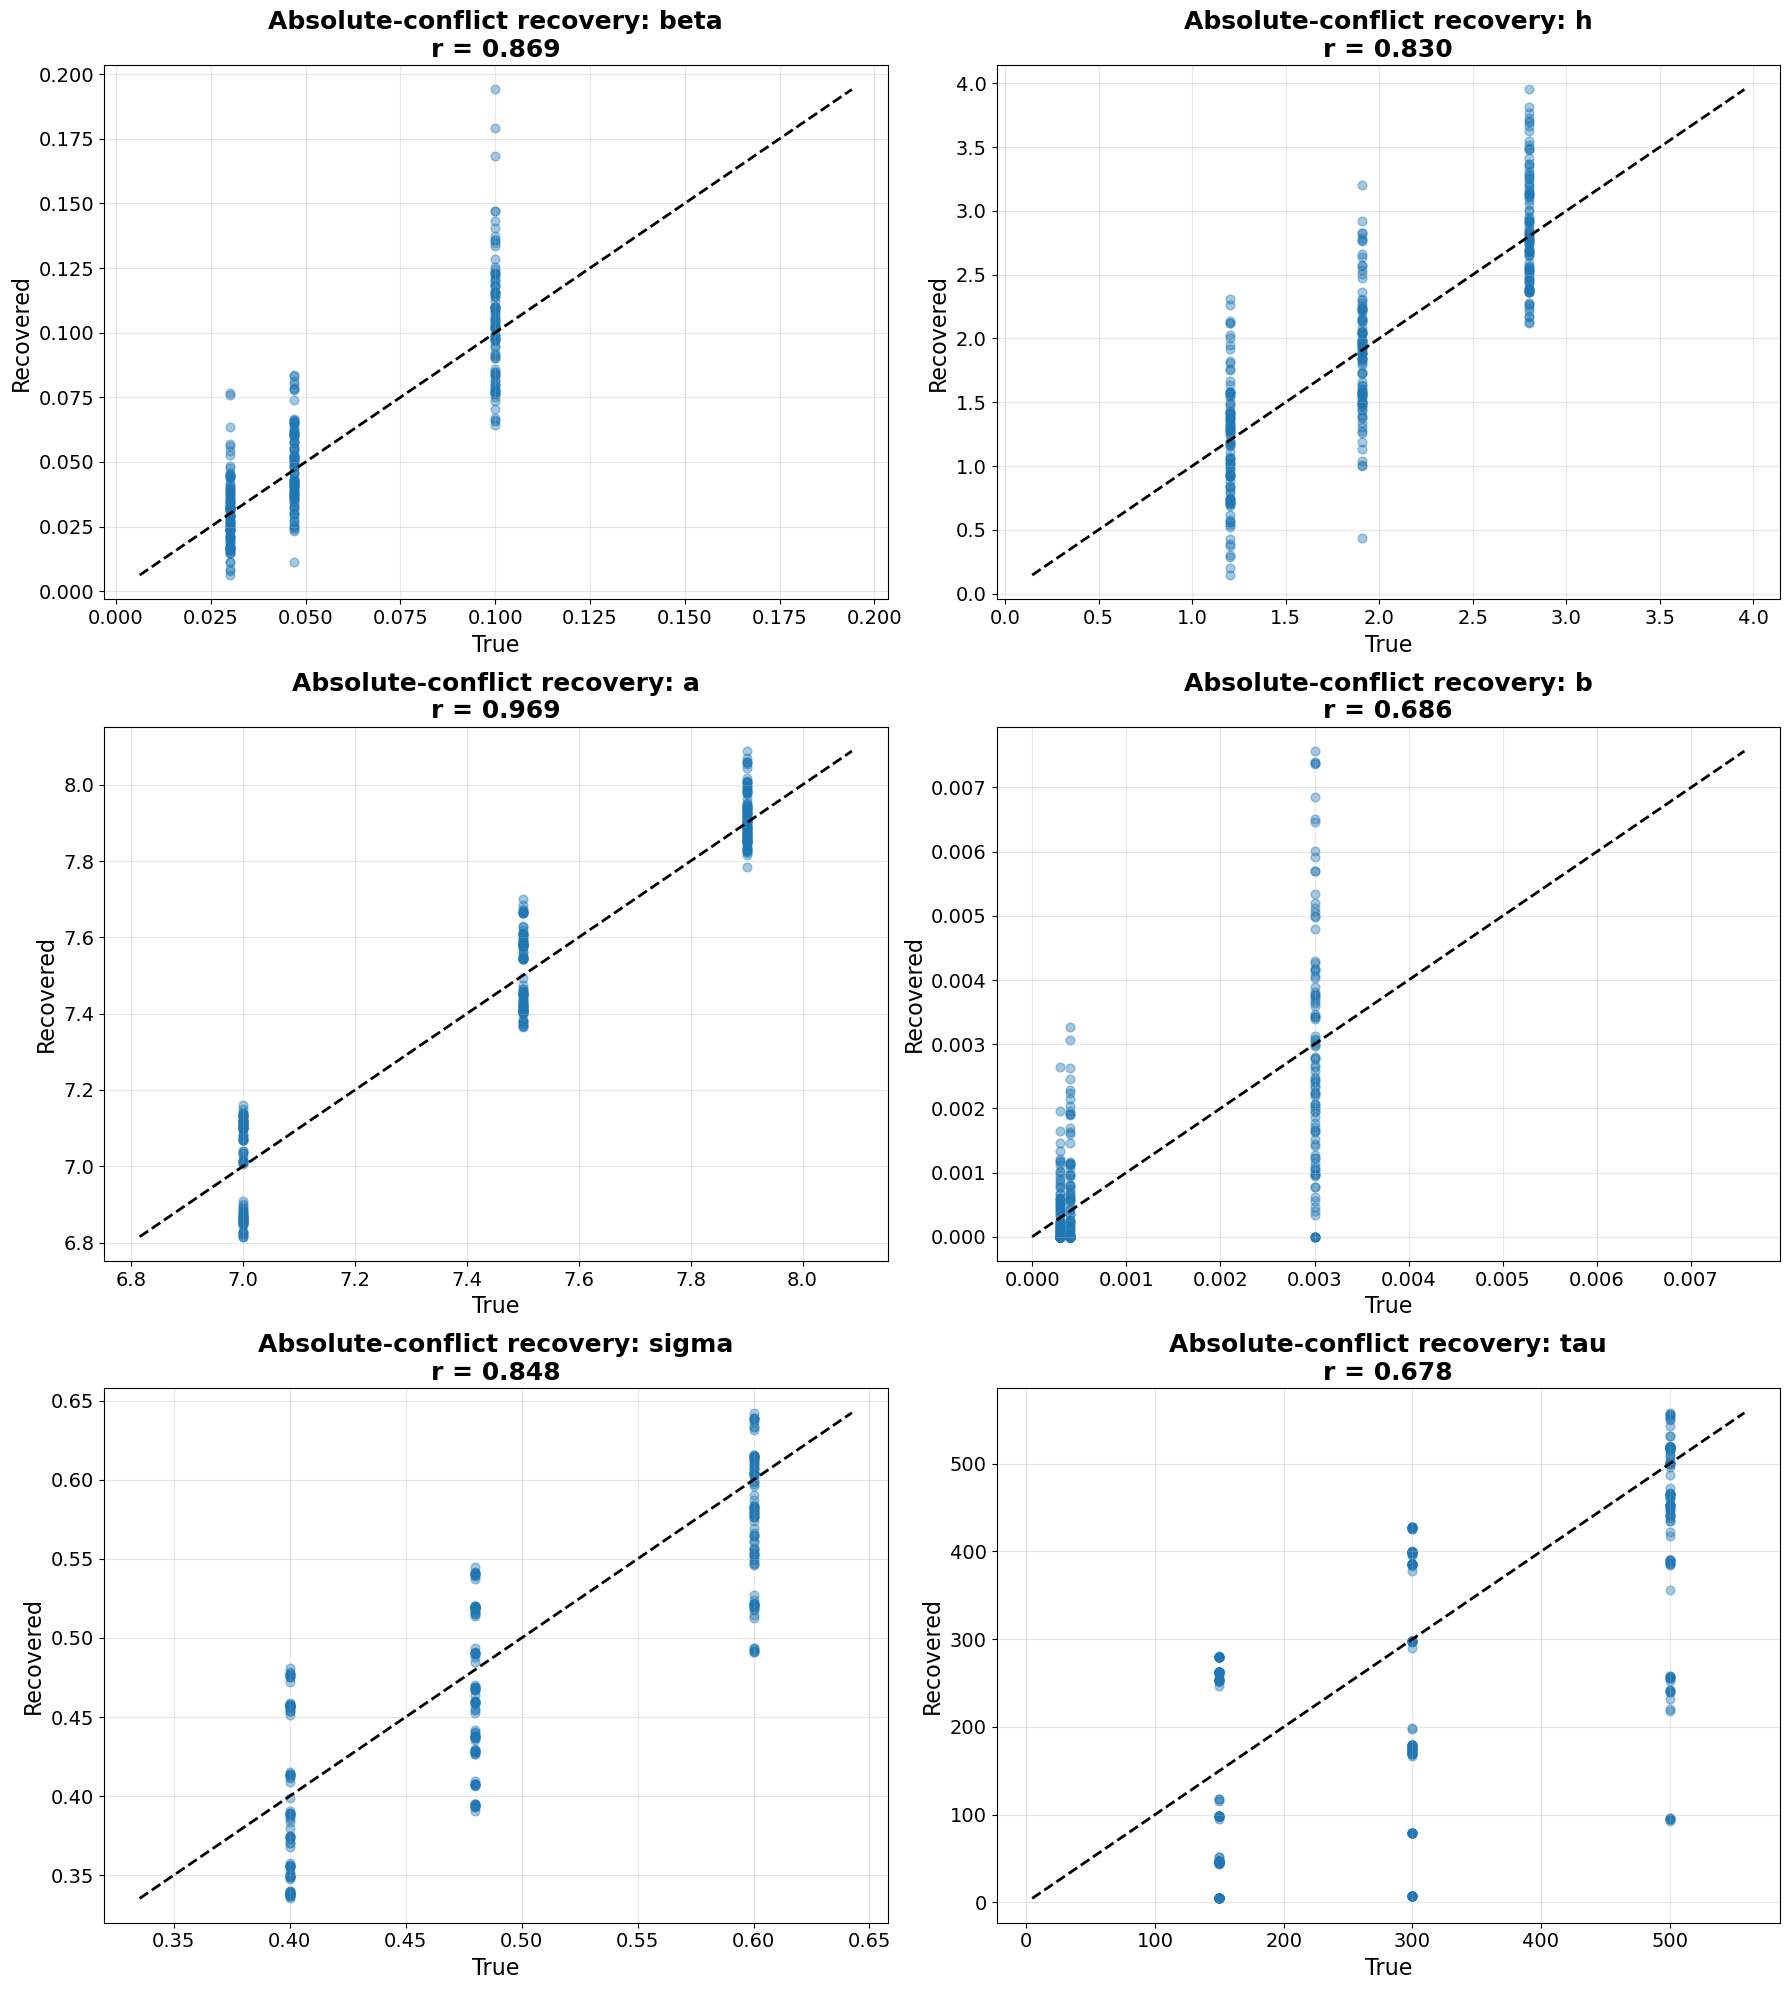

In [ ]:
parameters = ["beta", "h", "a", "b", "sigma", "tau"]

fig, axes = plt.subplots(3, 2, figsize=(18, 20))

axes = axes.ravel()

for ax, param in zip(axes, parameters):

    true_col = f"{param}_true"
    recovered_col = f"{param}_recovered"

    # Remove NaN values
    valid_data = df_abs_recovery.dropna(subset=[true_col, recovered_col])

    # Correlation
    if len(valid_data) < 2:
        r = np.nan
    else:
        r, _ = pearsonr(valid_data[true_col], valid_data[recovered_col])

    # Scatter plot
    ax.scatter(valid_data[true_col], valid_data[recovered_col], alpha=0.4, s=40)

    # Identity line: recovered = true
    min_val = min(valid_data[true_col].min(), valid_data[recovered_col].min())

    max_val = max(valid_data[true_col].max(), valid_data[recovered_col].max())

    ax.plot([min_val, max_val], [min_val, max_val], "--", color="black", linewidth=2)

    # Labels and title
    ax.set_xlabel("True", fontsize=16)

    ax.set_ylabel("Recovered", fontsize=16)

    ax.set_title(f"Absolute-conflict recovery: {param}\nr = {r:.3f}", fontsize=18, fontweight="bold")

    # Tick font size
    ax.tick_params(axis="both", labelsize=14)

    # Grid
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Reliability plots

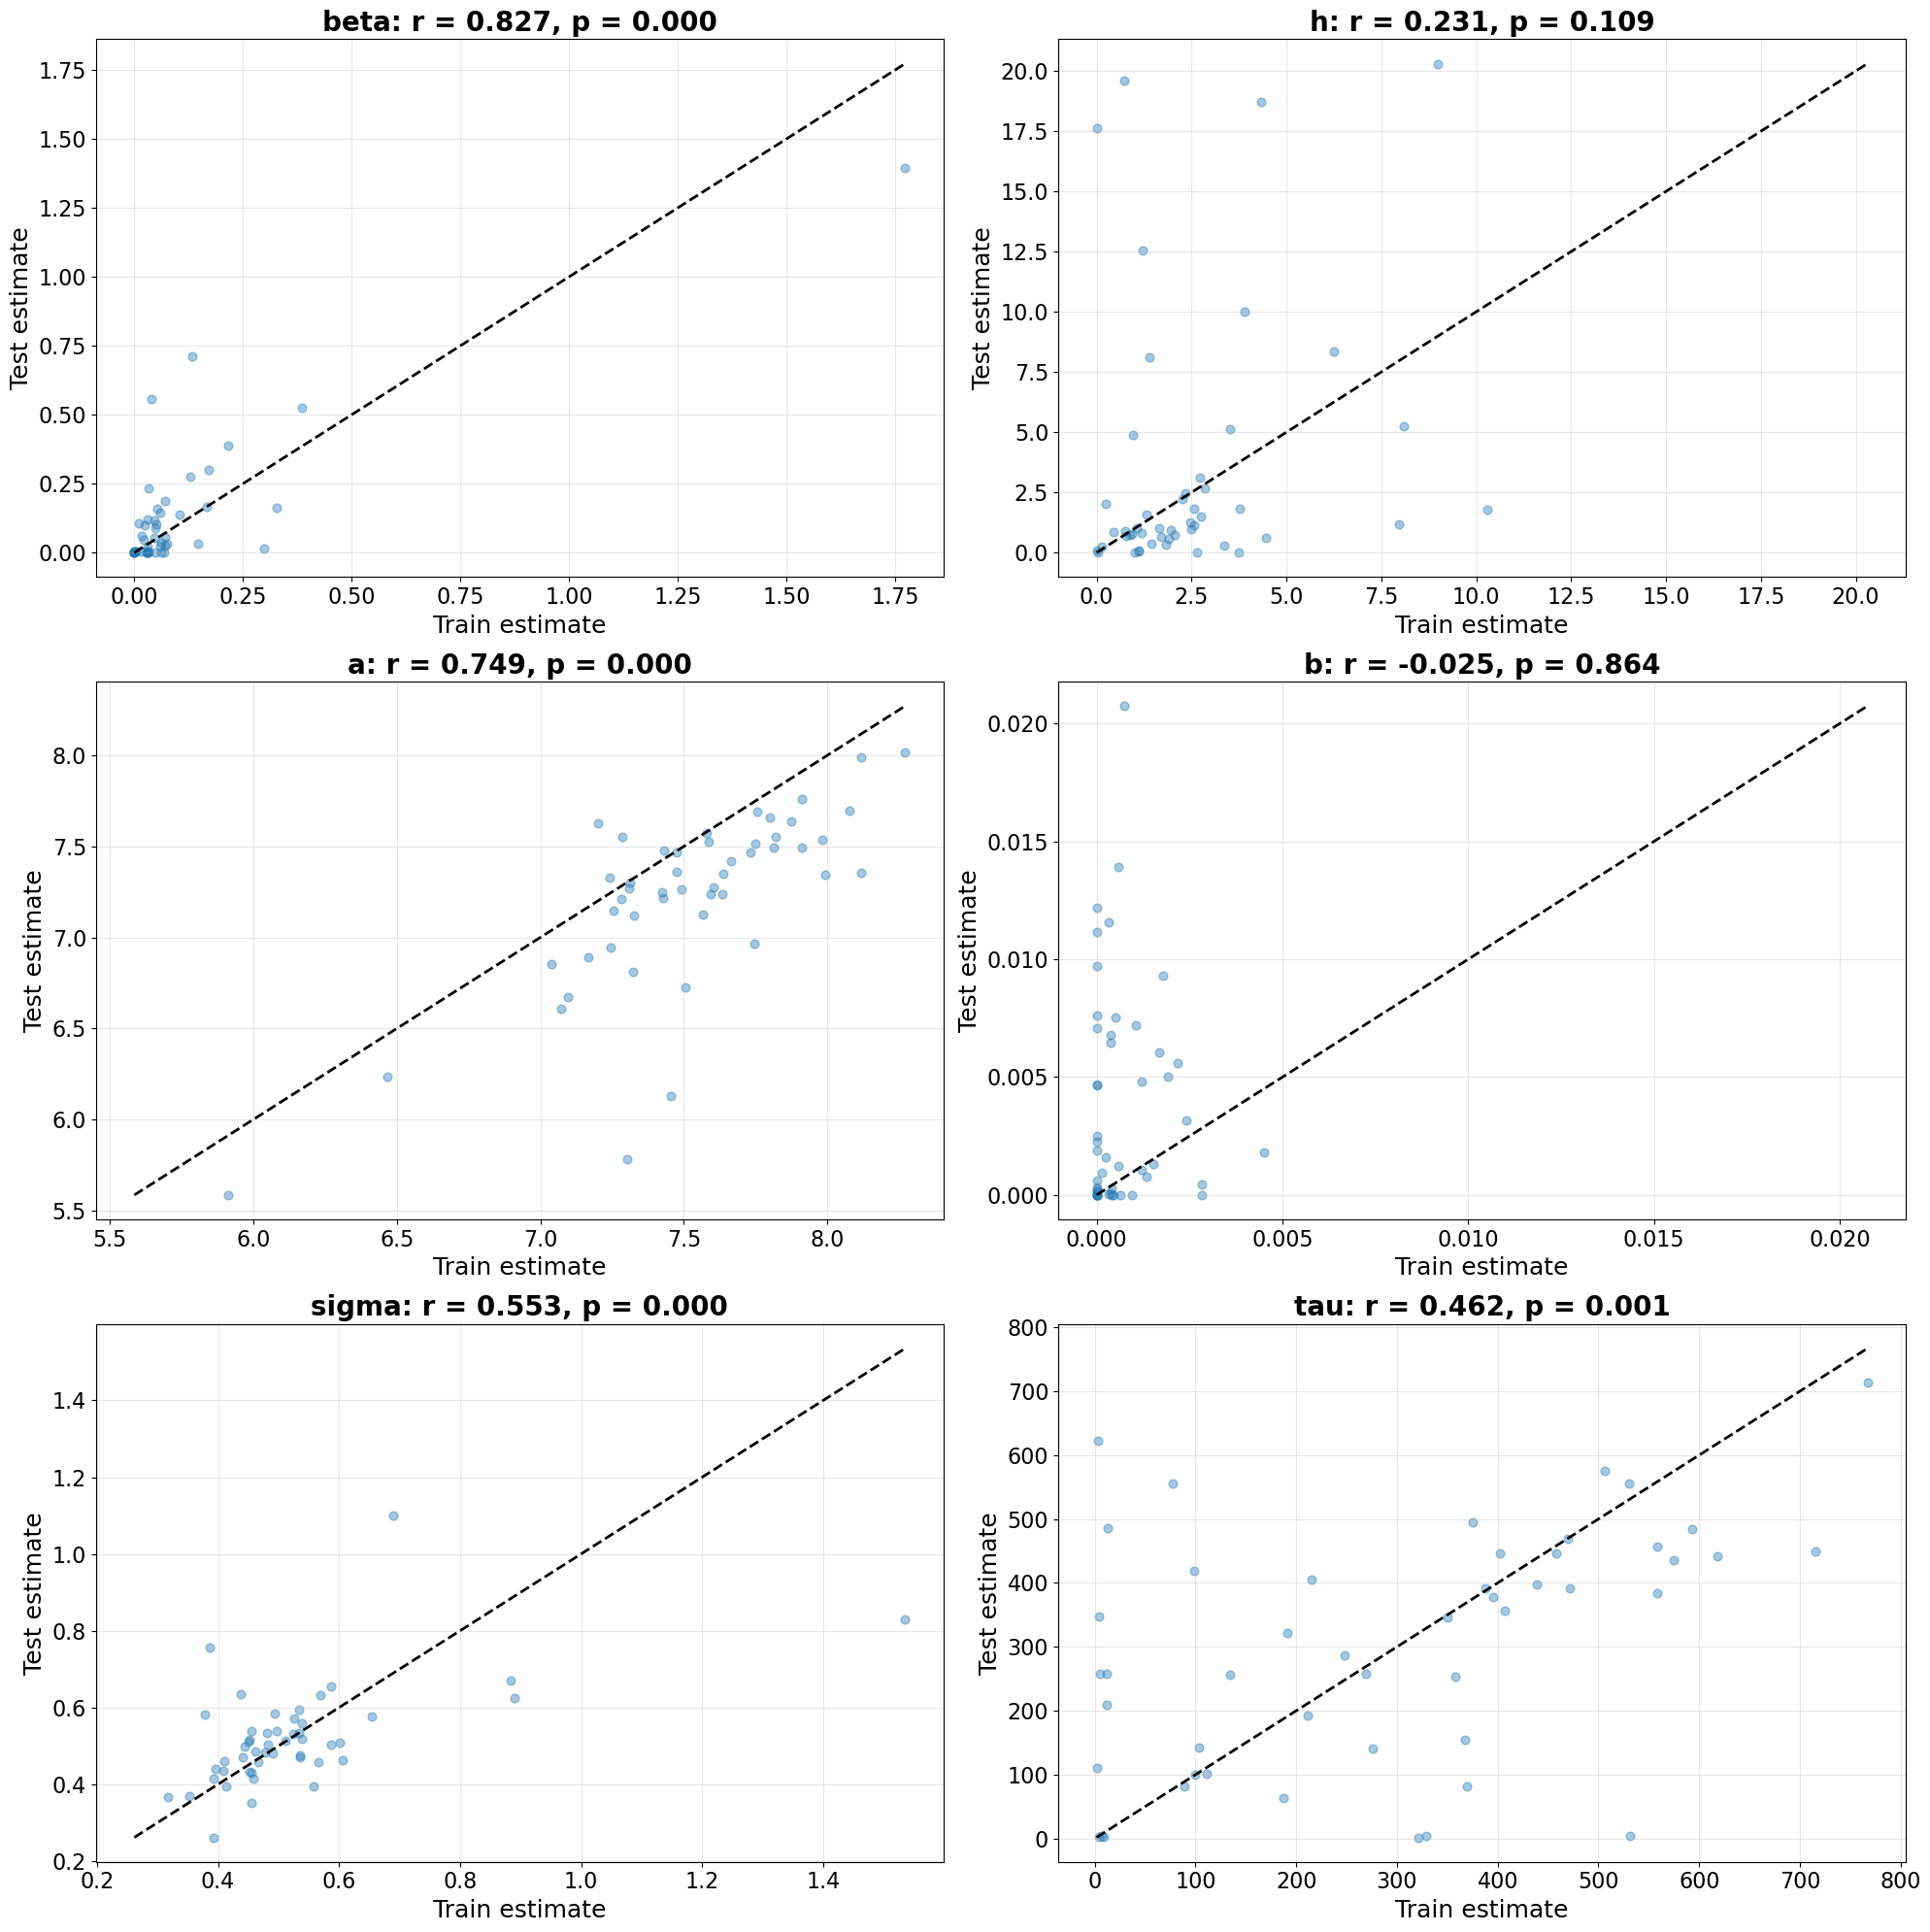

,model,parameter,r,p
0,absolute_conflict,beta,0.826906,2.466518e-13
1,absolute_conflict,h,0.231498,1.094926e-01
2,absolute_conflict,a,0.749181,5.941355e-10
3,absolute_conflict,b,-0.025039,8.644007e-01
4,absolute_conflict,sigma,0.553249,3.742247e-05
5,absolute_conflict,tau,0.461648,8.411890e-04


In [ ]:
abs_parameters = ["beta", "h", "a", "b", "sigma", "tau"]

abs_corr_results = []

fig, axes = plt.subplots(3, 2, figsize=(20, 20))

axes = axes.ravel()

for ax, param in zip(axes, abs_parameters):

    train_col = f"abs_train_{param}"
    test_col = f"abs_test_{param}"

    valid = (np.isfinite(df_abs_summary[train_col]) & np.isfinite(df_abs_summary[test_col]))

    r, p = compute_train_test_correlation(df_abs_summary, train_col, test_col)

    ax.scatter(df_abs_summary.loc[valid, train_col], df_abs_summary.loc[valid, test_col], alpha=0.4, s=40)

    # Identity line
    min_val = min(df_abs_summary.loc[valid, train_col].min(), df_abs_summary.loc[valid, test_col].min())

    max_val = max(df_abs_summary.loc[valid, train_col].max(), df_abs_summary.loc[valid, test_col].max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", linewidth=2)

    ax.set_xlabel("Train estimate", fontsize=18)

    ax.set_ylabel("Test estimate", fontsize=18)

    ax.set_title(f"{param}: r = {r:.3f}, p = {p:.3f}", fontsize=20, fontweight="bold")

    ax.tick_params(axis="both", labelsize=16)

    ax.grid(True, alpha=0.3)

    abs_corr_results.append({
        "model": "absolute_conflict",
        "parameter": param,
        "r": r,
        "p": p,
    })

plt.tight_layout()
plt.show()

df_abs_corr = pd.DataFrame(abs_corr_results)
df_abs_reliability


## Reward vs Loss
Compare prediction accuracy and likelihood measures for reward and loss trials.

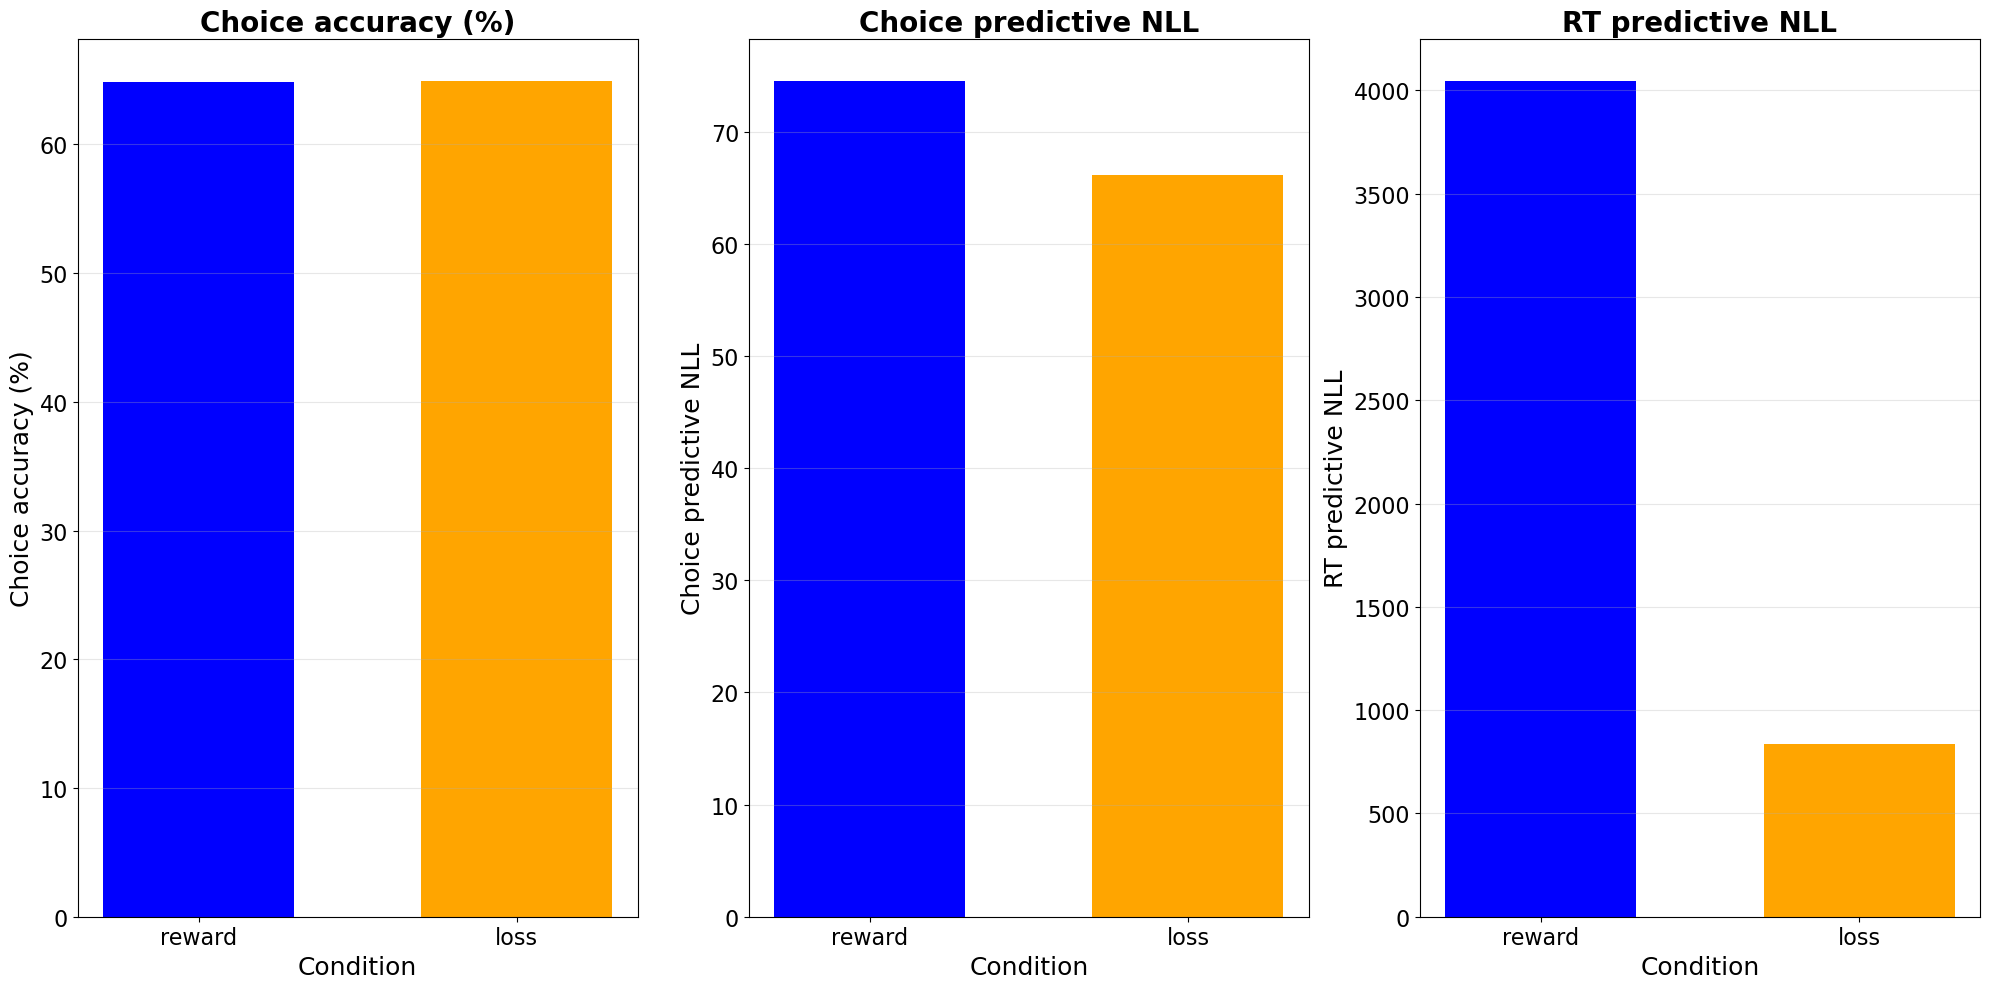

In [ ]:
condition_order = ["reward", "loss"]

condition_means = (
    df_abs_condition
    .groupby("condition", as_index=False)[
        [
            "abs_choice_accuracy",
            "abs_choice_nll",
            "abs_rt_nll"
        ]
    ]
    .mean()
    .set_index("condition")
    .reindex(condition_order)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

plot_metrics = [
    ("abs_choice_accuracy", "Choice accuracy (%)"),
    ("abs_choice_nll", "Choice predictive NLL"),
    ("abs_rt_nll", "RT predictive NLL"),
]

for ax, (metric, label) in zip(axes, plot_metrics):

    ax.bar(condition_means["condition"], condition_means[metric], color=["blue", "orange"], width=0.6)

    ax.set_xlabel("Condition", fontsize=18)

    ax.set_ylabel(label, fontsize=18)

    ax.set_title(label, fontsize=20, fontweight="bold")

    ax.tick_params(axis="both", labelsize=16)

    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Compare: absolute-conflict vs choice-only

In [ ]:
# Compare prediction accuracy: choice-only vs absolute-conflict

comparison_df = pd.DataFrame({
    "participant": df_choice_only["participant"],
    "choice_only_accuracy": df_choice_only["co_test_accuracy"],
    "absolute_accuracy": df_abs_summary["abs_test_pred_choice_accuracy"],
    "choice_only_nll": df_choice_only["co_test_nll"],
    "absolute_nll": df_abs_summary["abs_test_pred_choice_nll"]
})

comparison_df.describe()

,choice_only_accuracy,absolute_accuracy,choice_only_nll,absolute_nll
count,49.000000,49.000000,49.000000,49.000000
mean,64.400099,64.869538,147.032877,140.637187
std,15.376167,15.311220,77.596354,69.646264
min,31.500000,31.000000,96.260165,96.927937
25%,56.000000,56.000000,121.304311,120.878828
50%,66.666667,66.666667,128.669808,128.603399
75%,74.500000,74.500000,143.474291,138.629436
max,92.500000,92.500000,603.012893,603.017054


In [203]:
accuracy_stat, accuracy_p = wilcoxon(
    comparison_df["choice_only_accuracy"],
    comparison_df["absolute_accuracy"]
)

nll_stat, nll_p = wilcoxon(
    comparison_df["choice_only_nll"],
    comparison_df["absolute_nll"]
)

print(f"Accuracy comparison p = {accuracy_p:.4f}")
print(f"Choice NLL comparison p = {nll_p:.4f}")

Accuracy comparison p = 0.4946
Choice NLL comparison p = 0.6954


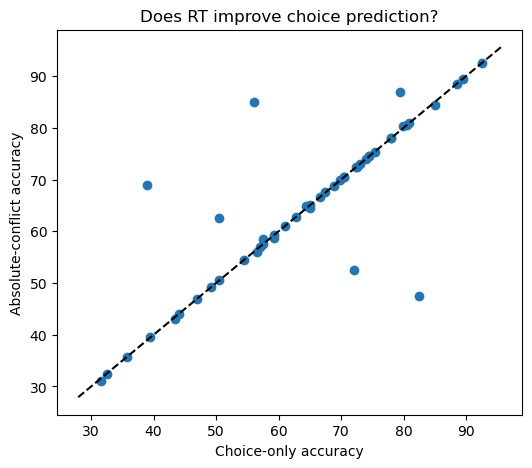

In [204]:
plt.figure(figsize=(6,5))

plt.scatter(
    comparison_df["choice_only_accuracy"],
    comparison_df["absolute_accuracy"]
)

lims = [
    min(plt.xlim()[0], plt.ylim()[0]),
    max(plt.xlim()[1], plt.ylim()[1])
]

plt.plot(lims, lims, "--", color="black")
plt.xlabel("Choice-only accuracy")
plt.ylabel("Absolute-conflict accuracy")
plt.title("Does RT improve choice prediction?")
plt.show()

In [205]:
# Compare parameter recovery: choice-only vs absolute-conflict

recovery_comparison = []

for param in ["beta", "h"]:

    # Choice-only recovery
    co_true = f"{param}_true"
    co_rec = f"{param}_recovered"

    co_valid = (
        np.isfinite(df_co_recovery[co_true])
        & np.isfinite(df_co_recovery[co_rec])
    )

    co_true_values = df_co_recovery.loc[co_valid, co_true]
    co_rec_values = df_co_recovery.loc[co_valid, co_rec]

    co_r, co_p = pearsonr(
        co_true_values,
        co_rec_values
    )

    co_rmse = np.sqrt(
        np.mean(
            (co_rec_values - co_true_values) ** 2
        )
    )

    co_bias = np.mean(
        co_rec_values - co_true_values
    )

    # Absolute-conflict recovery
    abs_row = df_abs_recovery_metrics[
        df_abs_recovery_metrics["parameter"] == param
    ].iloc[0]

    recovery_comparison.append({
        "parameter": param,

        "choice_only_r": co_r,
        "choice_only_p": co_p,
        "choice_only_rmse": co_rmse,
        "choice_only_bias": co_bias,

        "absolute_r": abs_row["correlation"],
        "absolute_p": abs_row["p"],
        "absolute_rmse": abs_row["rmse"],
        "absolute_bias": abs_row["bias"]
    })

df_recovery_comparison = pd.DataFrame(
    recovery_comparison
)

display(df_recovery_comparison)

,parameter,choice_only_r,choice_only_p,choice_only_rmse,choice_only_bias,absolute_r,absolute_p,absolute_rmse,absolute_bias
0,beta,0.362243,2.912646e-29,99.981716,22.267878,0.869168,3.899947e-93,0.018201,0.002277
1,h,0.995193,0.000000e+00,0.442721,0.021722,0.830209,1.301647e-77,0.468110,0.006097


In [207]:
# Compare train-test reliability: Choice-only vs Absolute-conflict

reliability_comparison = []

for param in ["beta", "h"]:

    # Choice-only

    co_train = f"co_train_{param}"
    co_test = f"co_test_{param}"

    co_valid = (
        np.isfinite(df_choice_only[co_train])
        & np.isfinite(df_choice_only[co_test])
    )

    if co_valid.sum() >= 3:
        co_r, co_p = pearsonr(
            df_choice_only.loc[co_valid, co_train],
            df_choice_only.loc[co_valid, co_test]
        )
    else:
        co_r, co_p = np.nan, np.nan

    # Absolute conflict

    abs_train = f"abs_train_{param}"
    abs_test = f"abs_test_{param}"

    abs_valid = (
        np.isfinite(df_abs_summary[abs_train])
        & np.isfinite(df_abs_summary[abs_test])
    )

    if abs_valid.sum() >= 3:
        abs_r, abs_p = pearsonr(
            df_abs_summary.loc[abs_valid, abs_train],
            df_abs_summary.loc[abs_valid, abs_test]
        )
    else:
        abs_r, abs_p = np.nan, np.nan

    reliability_comparison.append({
        "parameter": param,

        "choice_only_r": co_r,
        "choice_only_p": co_p,

        "absolute_conflict_r": abs_r,
        "absolute_conflict_p": abs_p,

        "N_choice_only": int(co_valid.sum()),
        "N_absolute": int(abs_valid.sum())
    })

df_reliability_comparison = pd.DataFrame(
    reliability_comparison
)

display(df_reliability_comparison)

,parameter,choice_only_r,choice_only_p,absolute_conflict_r,absolute_conflict_p,N_choice_only,N_absolute
0,beta,0.824633,3.263315e-13,0.826906,2.466518e-13,49,49
1,h,-0.037775,7.966440e-01,0.231498,1.094926e-01,49,49
